In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CombinedData = pd.read_csv("CombinedData.csv")
crime = pd.read_csv("CA_county_crime_FINAL.csv")

In [3]:
CombinedData.head()

,FIPS_Code,State,Area_Name,Attribute,Value,Dataset
0,6001,CA,Alameda County,Rural_Urban_Continuum_Code_2023,1.0,poverty
1,6001,CA,Alameda County,POVALL_2023,151872.0,poverty
2,6001,CA,Alameda County,CI90LBALL_2023,138959.0,poverty
3,6001,CA,Alameda County,CI90UBALL_2023,164785.0,poverty
4,6001,CA,Alameda County,PCTPOVALL_2023,9.5,poverty


In [4]:
#The area names weren't the same from the unemployment dataset
CombinedData["Area_Name"] = CombinedData["Area_Name"].str.replace(", CA", "", regex=False)
CombinedData["Area_Name"] = CombinedData["Area_Name"].replace(
    "San Francisco County/city",
    "San Francisco County"
)

In [5]:
#pivoting the data into a wide format to make it easier to analyze
CombinedData_Wide = CombinedData.pivot_table(
    index=["FIPS_Code", "State", "Area_Name"],
    columns="Attribute",
    values="Value",
    aggfunc="first"
).reset_index()

In [6]:
CombinedData_Wide.head()

Attribute,FIPS_Code,State,Area_Name,2023 Rural-urban Continuum Code,BIRTHS_2023,"Bachelor's degree or higher, 2019-23",CI90LB017P_2023,CI90LB017_2023,CI90LB517P_2023,CI90LB517_2023,...,R_BIRTH_2023,R_DEATH_2023,R_DOMESTIC_MIG_2023,R_INTERNATIONAL_MIG_2023,R_NATURAL_CHG_2023,R_NET_MIG_2023,Rural_Urban_Continuum_Code_2023,"Some college or associate degree, 2019-23",Unemployed_2023,Unemployment_rate_2023
0,6001,CA,Alameda County,1.0,16418.0,612435.0,7.1,22066.0,7.1,16450.0,...,10.1,6.5,-15.2,7.8,3.6,-7.3,1.0,256640.0,33663.0,4.1
1,6003,CA,Alpine County,8.0,7.0,496.0,18.5,34.0,14.9,21.0,...,6.0,18.9,-28.3,0.9,-12.9,-27.5,8.0,420.0,35.0,6.5
2,6005,CA,Amador County,6.0,331.0,7295.0,9.6,613.0,9.1,427.0,...,7.9,13.3,12.4,0.6,-5.3,13.0,6.0,13669.0,731.0,5.1
3,6007,CA,Butte County,3.0,1947.0,43218.0,17.2,7109.0,14.5,4485.0,...,9.4,11.5,0.1,1.1,-2.1,1.2,3.0,49524.0,4822.0,5.2
4,6009,CA,Calaveras County,6.0,376.0,7919.0,11.0,873.0,10.5,621.0,...,8.1,12.8,4.6,0.3,-4.7,4.9,6.0,14013.0,926.0,4.2


In [7]:
#merging incident count to the data
FinalData = CombinedData_Wide.merge(
    crime[["FIPS_Code", "incident_count"]],
    on="FIPS_Code",
    how="left"
)

In [8]:
#creating a new column for crime rate which is the crime per 100,000 people
FinalData["crime_rate"] = ( FinalData["incident_count"] / FinalData["POP_ESTIMATE_2023"]) * 100000

In [9]:
FinalData.head()

,FIPS_Code,State,Area_Name,2023 Rural-urban Continuum Code,BIRTHS_2023,"Bachelor's degree or higher, 2019-23",CI90LB017P_2023,CI90LB017_2023,CI90LB517P_2023,CI90LB517_2023,...,R_DOMESTIC_MIG_2023,R_INTERNATIONAL_MIG_2023,R_NATURAL_CHG_2023,R_NET_MIG_2023,Rural_Urban_Continuum_Code_2023,"Some college or associate degree, 2019-23",Unemployed_2023,Unemployment_rate_2023,incident_count,crime_rate
0,6001,CA,Alameda County,1.0,16418.0,612435.0,7.1,22066.0,7.1,16450.0,...,-15.2,7.8,3.6,-7.3,1.0,256640.0,33663.0,4.1,52408,3230.698291
1,6003,CA,Alpine County,8.0,7.0,496.0,18.5,34.0,14.9,21.0,...,-28.3,0.9,-12.9,-27.5,8.0,420.0,35.0,6.5,46,4031.551271
2,6005,CA,Amador County,6.0,331.0,7295.0,9.6,613.0,9.1,427.0,...,12.4,0.6,-5.3,13.0,6.0,13669.0,731.0,5.1,1564,3740.642415
3,6007,CA,Butte County,3.0,1947.0,43218.0,17.2,7109.0,14.5,4485.0,...,0.1,1.1,-2.1,1.2,3.0,49524.0,4822.0,5.2,9742,4702.372908
4,6009,CA,Calaveras County,6.0,376.0,7919.0,11.0,873.0,10.5,621.0,...,4.6,0.3,-4.7,4.9,6.0,14013.0,926.0,4.2,1533,3292.172232


In [10]:
#making a refined dataset with only the columns that seem relevant
analysis_df = FinalData[[
    "Area_Name",
    "crime_rate",
    "MEDHHINC_2023",
    "Unemployment_rate_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23",
    "Percent of adults who are not high school graduates, 2019-23",
    "Rural_Urban_Continuum_Code_2023"
]].copy()

In [11]:
#defining the rural urban continuum code
def classify_urban(code):
    if code <= 3:
        return "Metro"
    elif code <= 6:
        return "Suburban"
    else:
        return "Rural"

analysis_df["Urban_Category"] = analysis_df["Rural_Urban_Continuum_Code_2023"].apply(classify_urban)

In [12]:
analysis_df.head()

,Area_Name,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023,Urban_Category
0,Alameda County,3230.698291,119230.0,4.1,9.5,51.469365,11.100158,1.0,Metro
1,Alpine County,4031.551271,83265.0,6.5,15.6,42.105263,3.735144,8.0,Rural
2,Amador County,3740.642415,80767.0,5.1,11.7,22.443392,9.032734,6.0,Suburban
3,Butte County,4702.372908,63084.0,5.2,19.9,31.720564,9.672945,3.0,Metro
4,Calaveras County,3292.172232,77041.0,4.2,12.2,22.185802,6.653779,6.0,Suburban


In [13]:
analysis_df.describe()

,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,3365.274715,84634.293103,5.631034,13.251724,29.864695,13.913219,3.362069
std,1254.640755,23686.597808,2.423221,3.694341,12.354201,6.755905,2.497004
min,47.044065,51996.000000,3.000000,6.500000,13.212724,3.735144,1.000000
25%,2769.051897,66231.750000,4.100000,10.350000,20.271318,8.953489,1.000000
50%,3581.686264,81174.500000,5.050000,12.750000,25.003852,11.610344,2.000000
75%,4110.537100,99897.000000,6.375000,16.425000,38.747358,18.979062,5.750000
max,5924.864398,154573.000000,17.300000,20.800000,60.459166,28.152864,9.000000


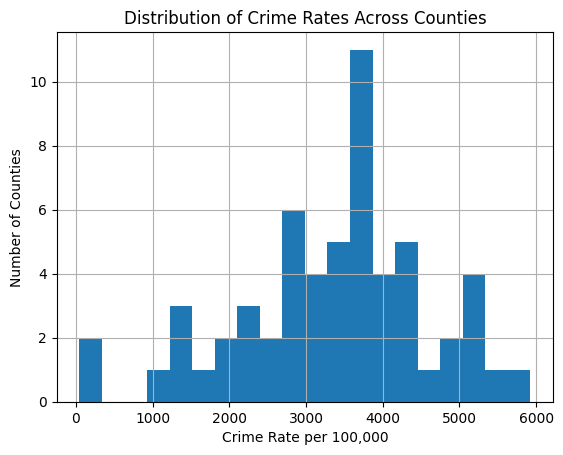

In [14]:
analysis_df["crime_rate"].hist(bins=20)
plt.title("Distribution of Crime Rates Across Counties")
plt.xlabel("Crime Rate per 100,000")
plt.ylabel("Number of Counties")
plt.show()

In [15]:
correlation = analysis_df.corr(numeric_only=True)
correlation

,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023
crime_rate,1.000000,-0.184409,0.105831,0.235104,-0.169697,0.130505,0.010788
MEDHHINC_2023,-0.184409,1.000000,-0.521170,-0.777607,0.839899,-0.269086,-0.589143
Unemployment_rate_2023,0.105831,-0.521170,1.000000,0.515206,-0.614540,0.678120,0.139313
PCTPOVALL_2023,0.235104,-0.777607,0.515206,1.000000,-0.606381,0.391691,0.347108
"Percent of adults with a bachelor's degree or higher, 2019-23",-0.169697,0.839899,-0.614540,-0.606381,1.000000,-0.520263,-0.402271
"Percent of adults who are not high school graduates, 2019-23",0.130505,-0.269086,0.678120,0.391691,-0.520263,1.000000,-0.265692
Rural_Urban_Continuum_Code_2023,0.010788,-0.589143,0.139313,0.347108,-0.402271,-0.265692,1.000000


In [16]:
##

In [17]:
print(analysis_df.isnull().sum())

Area_Name                                                        0
crime_rate                                                       0
MEDHHINC_2023                                                    0
Unemployment_rate_2023                                           0
PCTPOVALL_2023                                                   0
Percent of adults with a bachelor's degree or higher, 2019-23    0
Percent of adults who are not high school graduates, 2019-23     0
Rural_Urban_Continuum_Code_2023                                  0
Urban_Category                                                   0
dtype: int64


In [18]:
# basic outlier check using IQR for crime_rate
Q1 = analysis_df["crime_rate"].quantile(0.25)
Q3 = analysis_df["crime_rate"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = analysis_df[
    (analysis_df["crime_rate"] < lower_bound) |
    (analysis_df["crime_rate"] > upper_bound)
]
print("Potential outlier counties:")
print(outliers[["Area_Name", "crime_rate"]])

Potential outlier counties:
               Area_Name  crime_rate
31         Plumas County   47.044065
37  San Francisco County  100.743151


In [19]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

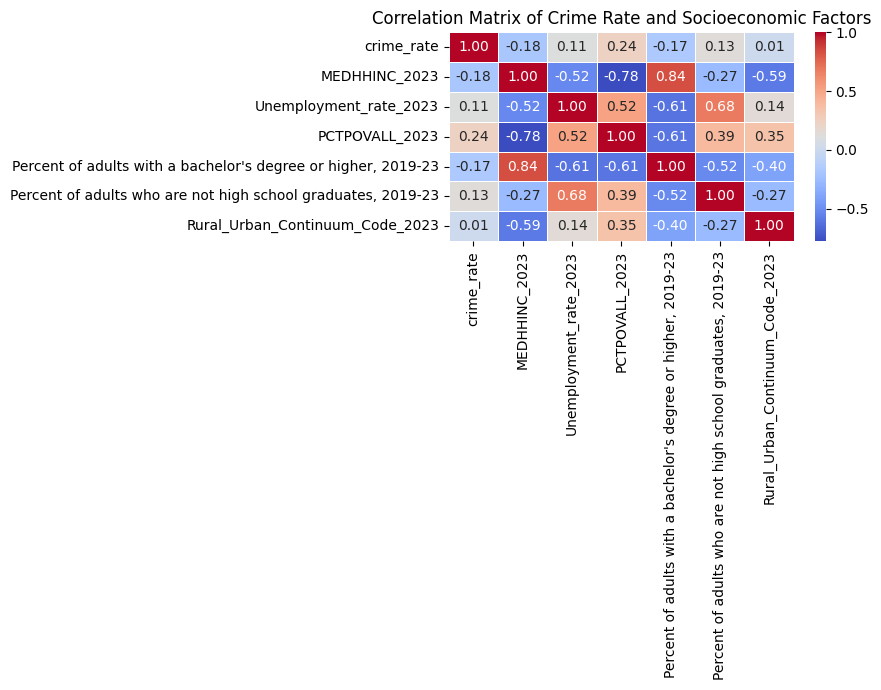

In [20]:
#Heatmap
plt.figure(figsize= (9, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Crime Rate and Socioeconomic Factors")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

Top 10 counties by crime_rate:
            Area_Name   crime_rate
51      Tehama County  5924.864398
53      Tulare County  5465.015392
11    Humboldt County  5272.978318
21    Mariposa County  5088.953248
16        Lake County  5078.228587
23      Merced County  5046.930666
13        Inyo County  4981.918281
47      Solano County  4966.408292
3        Butte County  4702.372908
33  Sacramento County  4421.986407

Bottom 10 counties by crime rate:
                Area_Name   crime_rate
31          Plumas County    47.044065
37   San Francisco County   100.743151
57            Yuba County  1208.557896
35  San Bernardino County  1305.786863
18     Los Angeles County  1423.202835
45          Sierra County  1437.500000
10           Glenn County  1734.864375
32       Riverside County  1880.926417
22       Mendocino County  1977.375769
43      Santa Cruz County  2266.896581


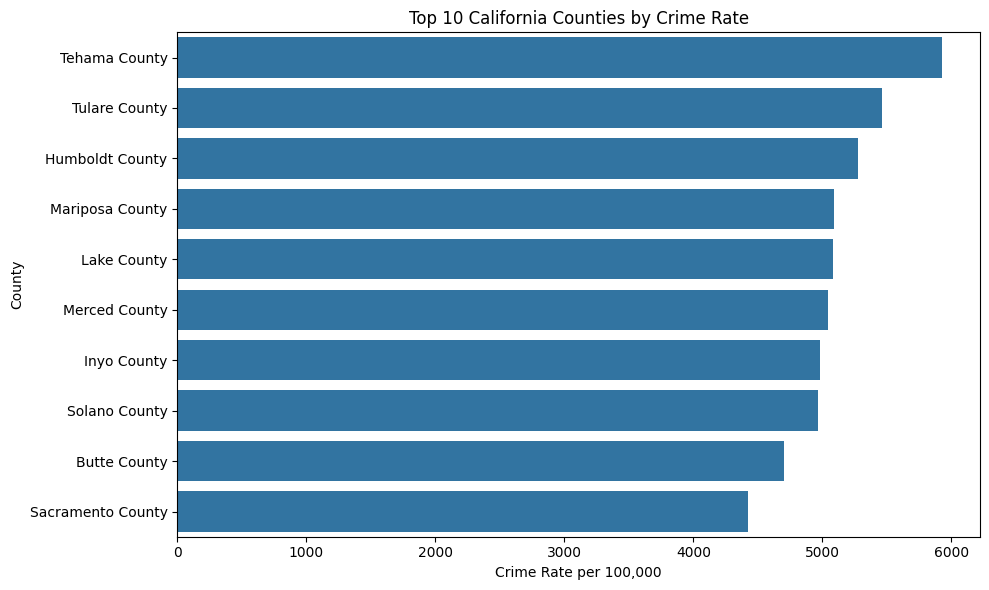

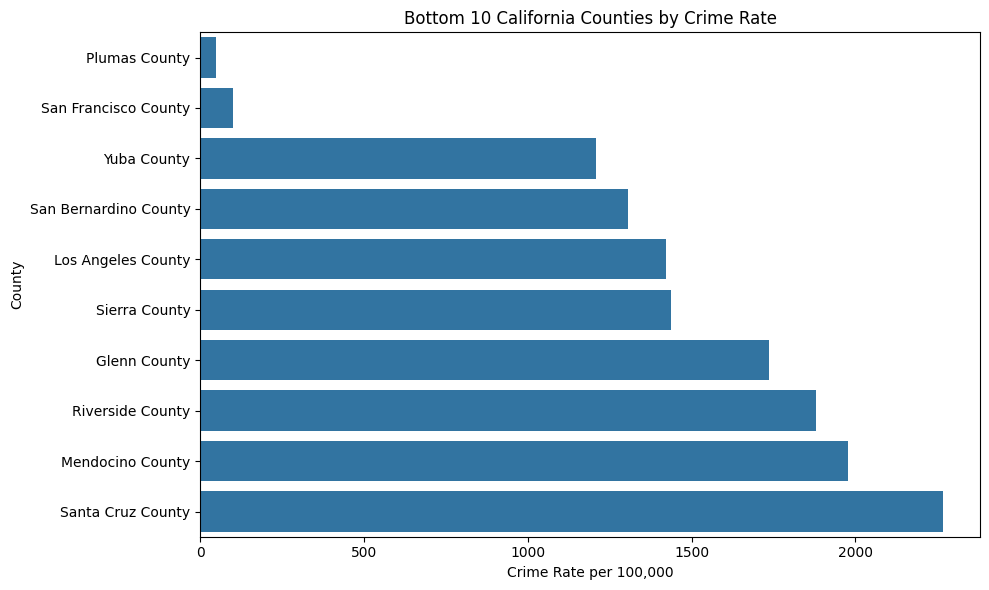

In [21]:
#top 10 and bottom 10 counties bar chart
top10 = analysis_df.sort_values("crime_rate", ascending=False).head(10)
bottom10 = analysis_df.sort_values("crime_rate", ascending=True).head(10)

print("Top 10 counties by crime_rate:")
print(top10[["Area_Name", "crime_rate"]])

print("\nBottom 10 counties by crime rate:")
print(bottom10[["Area_Name", "crime_rate"]])

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x ="crime_rate", y="Area_Name")
plt.title("Top 10 California Counties by Crime Rate")
plt.xlabel("Crime Rate per 100,000")
plt.ylabel("County")
plt.tight_layout()
plt.savefig("top10_crime_coounties.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=bottom10, x="crime_rate", y="Area_Name")
plt.title("Bottom 10 California Counties by Crime Rate")
plt.xlabel("Crime Rate per 100,000")
plt.ylabel("County")
plt.tight_layout()
plt.savefig("bottom10_crime_counties.png", dpi=300)
plt.show()

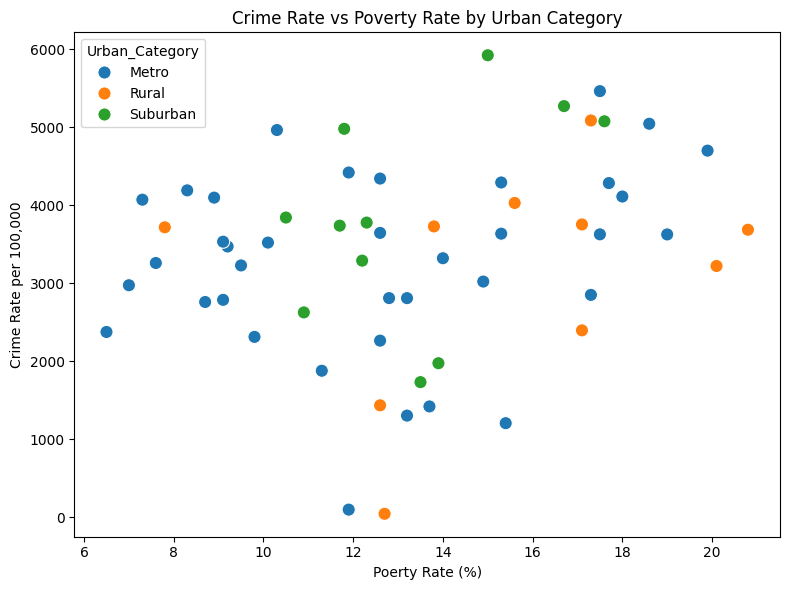

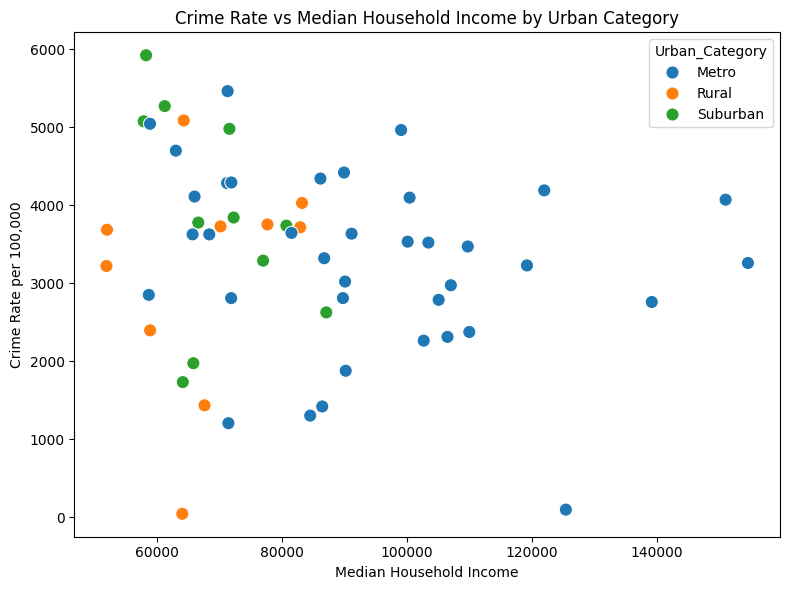

In [22]:
#Scatterplot with hue
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=analysis_df,
    x="PCTPOVALL_2023",
    y="crime_rate",
    hue="Urban_Category",
    s=90
)
plt.title("Crime Rate vs Poverty Rate by Urban Category")
plt.xlabel("Poerty Rate (%)")
plt.ylabel("Crime Rate per 100,000")
plt.tight_layout()
plt.savefig("poverty_vs_crime_by_urban.png", dpi=300)
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=analysis_df,
    x="MEDHHINC_2023",
    y="crime_rate",
    hue="Urban_Category",
    s=90
)
plt.title("Crime Rate vs Median Household Income by Urban Category")
plt.xlabel("Median Household Income")
plt.ylabel("Crime Rate per 100,000")
plt.tight_layout()
plt.savefig("income_vs_crime_by_urban.png", dpi=300)
plt.show()

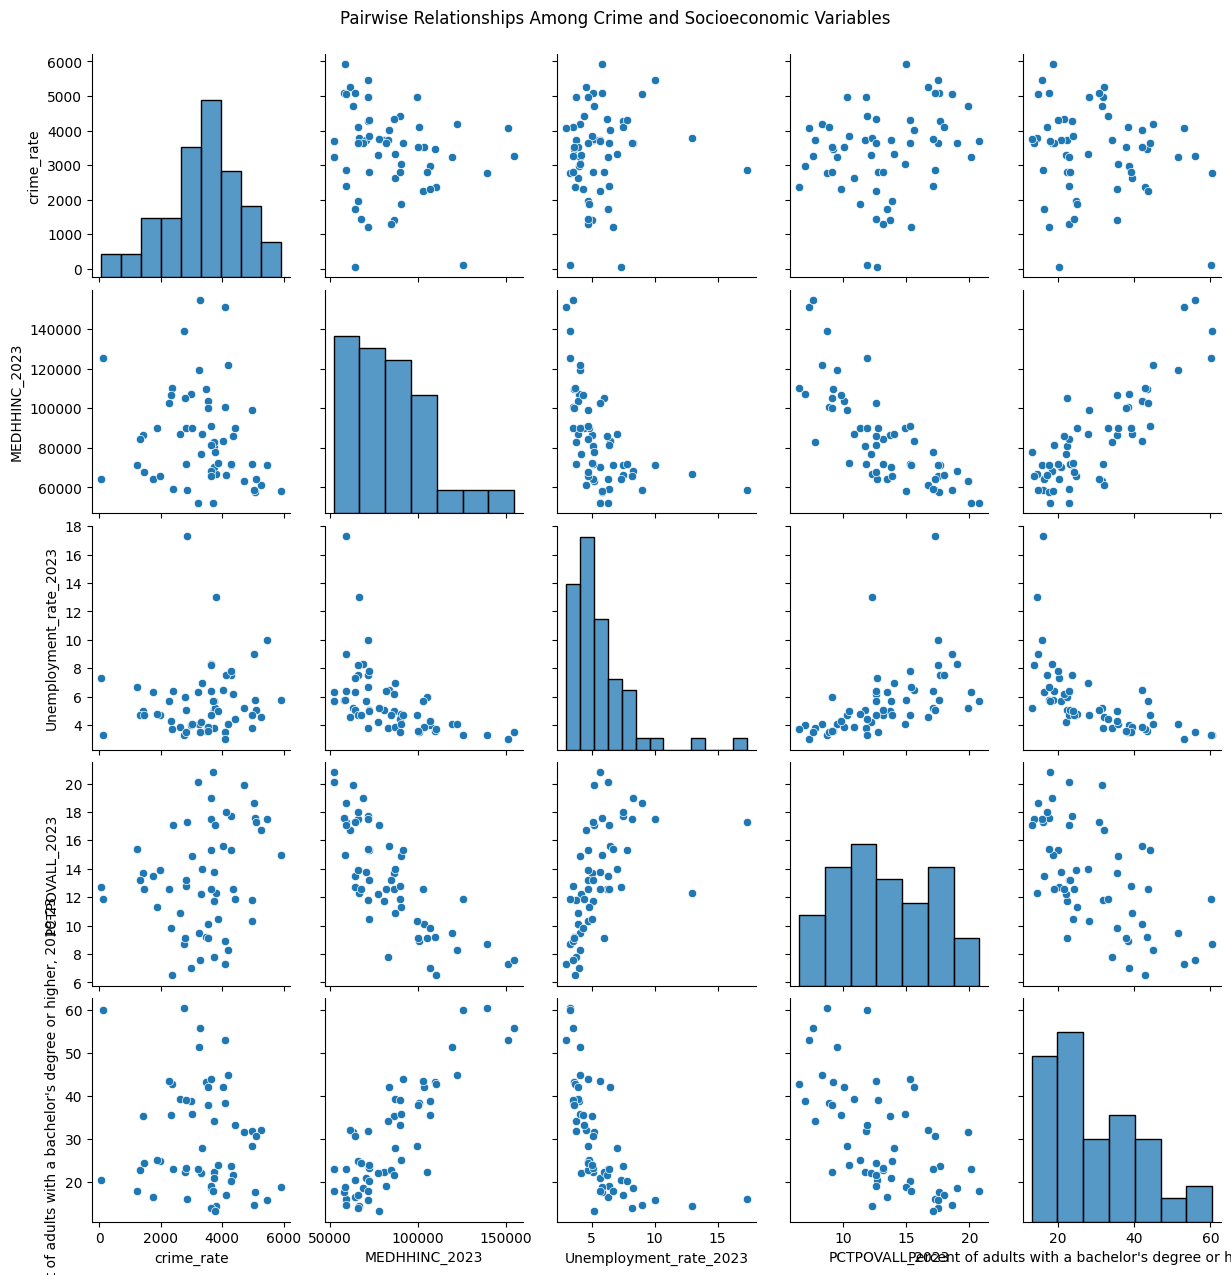

In [23]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
pair_df = analysis_df[[
    "crime_rate",
    "MEDHHINC_2023",
    "Unemployment_rate_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23"
]].copy()

g = sns.pairplot(pair_df)
g.figure.suptitle("Pairwise Relationships Among Crime and Socioeconomic Variables", y=1.02)
g.savefig("figures/pairplot_crime_socioeconomic.png", dpi=300)
plt.show()
plt.close()

In [25]:
#Plotnine scatter
import plotnine as p9
p = (
    p9.ggplot(
        analysis_df,
        p9.aes(
            x="PCTPOVALL_2023",
            y="crime_rate",
            color="Urban_Category"
        )
    )
    + p9.geom_point(size=3, alpha=0.8)
    + p9.geom_smooth(method="lm", se=False)
    + p9.labs(
        title="Crime Rate vs Poverty Rate",
        x="Poverty Rate (%)",
        y="Crime Rate per 100,000"
    )
    +p9.theme_classic()
)
print(p)
p9.ggsave(p, "figures/plotnine_poverty_vs_crime.png", width=7, height=5, units="in")
    

<ggplot: (640 x 480)>


In [26]:
#summary statisics table
summary_table = analysis_df[[
    "crime_rate",
    "MEDHHINC_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23",
    "Percent of adults who are not high school graduates, 2019-23"
]].describe().round(2)

print(summary_table)
summary_table.to_csv("tables/summary_statistics.csv")

       crime_rate  MEDHHINC_2023  PCTPOVALL_2023  \
count       58.00          58.00           58.00   
mean      3365.27       84634.29           13.25   
std       1254.64       23686.60            3.69   
min         47.04       51996.00            6.50   
25%       2769.05       66231.75           10.35   
50%       3581.69       81174.50           12.75   
75%       4110.54       99897.00           16.42   
max       5924.86      154573.00           20.80   

       Percent of adults with a bachelor's degree or higher, 2019-23  \
count                                              58.00               
mean                                               29.86               
std                                                12.35               
min                                                13.21               
25%                                                20.27               
50%                                                25.00               
75%                        

In [27]:
urban_summary = analysis_df.groupby("Urban_Category").agg({
    "crime_rate": ["mean", "median", "std"],
    "MEDHHINC_2023": "mean",
    "PCTPOVALL_2023": "mean",
    "Unemployment_rate_2023": "mean",
    "Percent of adults with a bachelor's degree or higher, 2019-23": "mean"
}).round(2)

print(urban_summary)
urban_summary.to_csv("tables/urban_summary.csv")

               crime_rate                   MEDHHINC_2023 PCTPOVALL_2023  \
                     mean   median      std          mean           mean   
Urban_Category                                                             
Metro             3292.10  3473.55  1160.69      93840.43          12.64   
Rural             3112.19  3704.08  1451.93      67341.00          15.49   
Suburban          3841.48  3780.01  1375.49      69389.36          13.28   

               Unemployment_rate_2023  \
                                 mean   
Urban_Category                          
Metro                            5.61   
Rural                            5.67   
Suburban                         5.65   

               Percent of adults with a bachelor's degree or higher, 2019-23  
                                                                        mean  
Urban_Category                                                                
Metro                                                      

In [28]:
import statsmodels.api as sm

reg_df = analysis_df[[
    "crime_rate",
    "MEDHHINC_2023",
    "Unemployment_rate_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23"
]].dropna()

X = reg_df[[
    "MEDHHINC_2023",
    "Unemployment_rate_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23"
]]
y = reg_df["crime_rate"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())
with open("tables/regression_summary.txt", "w") as f:
    f.write(model.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:             crime_rate   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.8370
Date:                Sun, 15 Mar 2026   Prob (F-statistic):              0.508
Time:                        02:49:10   Log-Likelihood:                -493.82
No. Observations:                  58   AIC:                             997.6
Df Residuals:                      53   BIC:                             1008.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------